# ListenBrainz Star Schema Prediction Model Notebook

This notebook uses the **dbt star schema tables** created from the ListenBrainz dataset to build a simple machine learning enhancement.

## Objective

Use the star schema output to predict whether a user is likely to repeatedly listen to a track.

## Source star schema tables

- `fact_listening_events`
- `dim_user`
- `dim_track`
- `dim_artist`
- `dim_album`
- `dim_date`
- `dim_time`

## ML target

`repeated_listen`

- `1` = user listened to a track more than once
- `0` = user listened to a track once only

This supports a future **music recommendation model**.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Install required packages

In [2]:
!pip install google-cloud-bigquery pandas db-dtypes scikit-learn matplotlib


## 2. Configure BigQuery connection

Update the service account key path to match your computer.


In [3]:
import os

# Change this path to your actual service account JSON key file
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"/content/drive/MyDrive/keys/my-project-sssint1-7e02e9078e06.json"

PROJECT_ID = "my-project-sssint1"
DATASET = "listenbrainz_gcp"

print("Project:", PROJECT_ID)
print("Dataset:", DATASET)


Project: my-project-sssint1
Dataset: listenbrainz_gcp


## 3. Load ML dataset from star schema

This query joins the fact table with dimension tables to create a machine learning dataset.

The query uses a limit to keep the notebook fast. Increase the limit after testing.


In [4]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project=PROJECT_ID)

query = f"""
SELECT
    u.user_name,
    t.track_id,
    t.track_name,
    t.artist_name AS track_artist_name,
    ar.artist_id,
    ar.artist_name,
    al.album_id,
    al.release_name,
    d.day_of_week,
    d.is_weekend,
    d.month,
    d.year,
    tm.hour,
    tm.time_period,
    COUNT(*) AS listen_count
FROM `{PROJECT_ID}.{DATASET}.fact_listening_events` f

LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_user` u
    ON f.user_id = u.user_id

LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_track` t
    ON f.track_id = t.track_id

LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_artist` ar
    ON f.artist_id = ar.artist_id

LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_album` al
    ON f.album_id = al.album_id

LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_date` d
    ON f.date_id = d.date_id

LEFT JOIN `{PROJECT_ID}.{DATASET}.dim_time` tm
    ON f.time_id = tm.time_id

WHERE u.user_name IS NOT NULL
  AND t.track_id IS NOT NULL
  AND t.track_name IS NOT NULL
  AND ar.artist_name IS NOT NULL

GROUP BY
    u.user_name,
    t.track_id,
    t.track_name,
    track_artist_name,
    ar.artist_id,
    ar.artist_name,
    al.album_id,
    al.release_name,
    d.day_of_week,
    d.is_weekend,
    d.month,
    d.year,
    tm.hour,
    tm.time_period

LIMIT 50000
"""

model_df = client.query(query).to_dataframe()
model_df.head()


,user_name,track_id,track_name,track_artist_name,artist_id,artist_name,album_id,release_name,day_of_week,is_weekend,month,year,hour,time_period,listen_count
0,fiveplustwo,a40a230d8d595e8087f485709955d025,Blood of the Sunsets,At the Gates,d75225bb06a04813a4cce60b4d5cdb7b,At the Gates,0fe8bd9c85545a9c0bf0d95ad07d9957,,Monday,False,4,2009,0,Night,1
1,stas.sh,682b52eeb1b358e5d44d47833556f01d,Granted,Cinder,983fbbc458acc945ec6ff63ff7867857,Cinder,1da670b8a04406fc08f326050c101ec4,,Thursday,False,3,2007,0,Night,1
2,jimzhou,f4458536773e16156a07413657ddaafa,Riot Van,Arctic Monkeys,def9ce6960c9295f792c721a8f490015,Arctic Monkeys,0218fbb5c69d452a8d69a80062bf6a6f,,Tuesday,False,7,2010,0,Night,1
3,l2yz,92b2315d082c483b704cc2c98cbb536f,虫男,ゆらゆら帝国,6284e92147e911857c56f8b8d05a0eca,ゆらゆら帝国,53d0bba9d5c5a4170729296657bb06f6,ゆらゆら帝国,Monday,False,6,2010,0,Night,1
4,Tricksta_P,a1332538cc4eb41f02eed7e2b00d774a,Weakness Within,Sigh,0ecdd68bcceabd005336b10685a589d6,Sigh,10defd2c6938d517052472ceaa38f800,,Tuesday,False,1,2016,0,Night,1


## 4. Basic checks

In [5]:
print("Rows:", len(model_df))
print("Unique users:", model_df["user_name"].nunique())
print("Unique tracks:", model_df["track_id"].nunique())
print("Unique artists:", model_df["artist_name"].nunique())
print("Columns:", model_df.columns.tolist())

model_df.isnull().sum()


Rows: 50000
Unique users: 1956
Unique tracks: 46154
Unique artists: 16806
Columns: ['user_name', 'track_id', 'track_name', 'track_artist_name', 'artist_id', 'artist_name', 'album_id', 'release_name', 'day_of_week', 'is_weekend', 'month', 'year', 'hour', 'time_period', 'listen_count']


,0
user_name,0
track_id,0
track_name,0
track_artist_name,0
artist_id,0
artist_name,0
album_id,0
release_name,0
day_of_week,0
is_weekend,0


## 5. Create target variable

The model predicts whether the user repeatedly listened to the same track.


In [6]:
model_df["repeated_listen"] = (model_df["listen_count"] > 1).astype(int)

model_df["repeated_listen"].value_counts()


,count
repeated_listen,
0,47988
1,2012


## 6. Create popularity and activity features

These features are created from the star schema ML dataset.


In [7]:
track_popularity = (
    model_df.groupby("track_id")["listen_count"]
    .sum()
    .reset_index(name="track_total_listens")
)

artist_popularity = (
    model_df.groupby("artist_id")["listen_count"]
    .sum()
    .reset_index(name="artist_total_listens")
)

user_activity = (
    model_df.groupby("user_name")["listen_count"]
    .sum()
    .reset_index(name="user_total_listens")
)

model_df = model_df.merge(track_popularity, on="track_id", how="left")
model_df = model_df.merge(artist_popularity, on="artist_id", how="left")
model_df = model_df.merge(user_activity, on="user_name", how="left")

model_df.head()


,user_name,track_id,track_name,track_artist_name,artist_id,artist_name,album_id,release_name,day_of_week,is_weekend,month,year,hour,time_period,listen_count,repeated_listen,track_total_listens,artist_total_listens,user_total_listens
0,fiveplustwo,a40a230d8d595e8087f485709955d025,Blood of the Sunsets,At the Gates,d75225bb06a04813a4cce60b4d5cdb7b,At the Gates,0fe8bd9c85545a9c0bf0d95ad07d9957,,Monday,False,4,2009,0,Night,1,0,1,17,25
1,stas.sh,682b52eeb1b358e5d44d47833556f01d,Granted,Cinder,983fbbc458acc945ec6ff63ff7867857,Cinder,1da670b8a04406fc08f326050c101ec4,,Thursday,False,3,2007,0,Night,1,0,1,1,173
2,jimzhou,f4458536773e16156a07413657ddaafa,Riot Van,Arctic Monkeys,def9ce6960c9295f792c721a8f490015,Arctic Monkeys,0218fbb5c69d452a8d69a80062bf6a6f,,Tuesday,False,7,2010,0,Night,1,0,4,180,23
3,l2yz,92b2315d082c483b704cc2c98cbb536f,虫男,ゆらゆら帝国,6284e92147e911857c56f8b8d05a0eca,ゆらゆら帝国,53d0bba9d5c5a4170729296657bb06f6,ゆらゆら帝国,Monday,False,6,2010,0,Night,1,0,1,4,50
4,Tricksta_P,a1332538cc4eb41f02eed7e2b00d774a,Weakness Within,Sigh,0ecdd68bcceabd005336b10685a589d6,Sigh,10defd2c6938d517052472ceaa38f800,,Tuesday,False,1,2016,0,Night,1,0,1,13,211


## 7. Encode categorical variables

In [8]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in ["user_name", "track_id", "artist_id", "day_of_week", "time_period"]:
    encoder = LabelEncoder()
    model_df[col] = model_df[col].astype(str)
    model_df[col + "_encoded"] = encoder.fit_transform(model_df[col])
    encoders[col] = encoder

model_df.head()


,user_name,track_id,track_name,track_artist_name,artist_id,artist_name,album_id,release_name,day_of_week,is_weekend,...,listen_count,repeated_listen,track_total_listens,artist_total_listens,user_total_listens,user_name_encoded,track_id_encoded,artist_id_encoded,day_of_week_encoded,time_period_encoded
0,fiveplustwo,a40a230d8d595e8087f485709955d025,Blood of the Sunsets,At the Gates,d75225bb06a04813a4cce60b4d5cdb7b,At the Gates,0fe8bd9c85545a9c0bf0d95ad07d9957,,Monday,False,...,1,0,1,17,25,990,29696,14154,1,3
1,stas.sh,682b52eeb1b358e5d44d47833556f01d,Granted,Cinder,983fbbc458acc945ec6ff63ff7867857,Cinder,1da670b8a04406fc08f326050c101ec4,,Thursday,False,...,1,0,1,1,173,1761,18889,9921,4,3
2,jimzhou,f4458536773e16156a07413657ddaafa,Riot Van,Arctic Monkeys,def9ce6960c9295f792c721a8f490015,Arctic Monkeys,0218fbb5c69d452a8d69a80062bf6a6f,,Tuesday,False,...,1,0,4,180,23,1185,44014,14619,5,3
3,l2yz,92b2315d082c483b704cc2c98cbb536f,虫男,ゆらゆら帝国,6284e92147e911857c56f8b8d05a0eca,ゆらゆら帝国,53d0bba9d5c5a4170729296657bb06f6,ゆらゆら帝国,Monday,False,...,1,0,1,4,50,1276,26559,6430,1,3
4,Tricksta_P,a1332538cc4eb41f02eed7e2b00d774a,Weakness Within,Sigh,0ecdd68bcceabd005336b10685a589d6,Sigh,10defd2c6938d517052472ceaa38f800,,Tuesday,False,...,1,0,1,13,211,557,29179,988,5,3


## 8. Prepare features and train/test split

In [9]:
from sklearn.model_selection import train_test_split

features = [
    "user_name_encoded",
    "track_id_encoded",
    "artist_id_encoded",
    "day_of_week_encoded",
    "time_period_encoded",
    "is_weekend",
    "month",
    "hour",
    "track_total_listens",
    "artist_total_listens",
    "user_total_listens"
]

# Convert boolean to integer
model_df["is_weekend"] = model_df["is_weekend"].astype(int)

X = model_df[features]
y = model_df["repeated_listen"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if y.nunique() > 1 else None
)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))


Train rows: 40000
Test rows: 10000


## 9. Baseline model: Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred, zero_division=0))
print("Recall:", recall_score(y_test, log_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, log_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, log_pred, zero_division=0))


Logistic Regression Results
Accuracy: 0.958
Precision: 0.40625
Recall: 0.09701492537313433
F1 Score: 0.1566265060240964

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      9598
           1       0.41      0.10      0.16       402

    accuracy                           0.96     10000
   macro avg       0.68      0.55      0.57     10000
weighted avg       0.94      0.96      0.95     10000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 10. Improved model: Random Forest Classifier

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, zero_division=0))
print("Recall:", recall_score(y_test, rf_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, rf_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, zero_division=0))


Random Forest Results
Accuracy: 0.9633
Precision: 0.6377952755905512
Recall: 0.20149253731343283
F1 Score: 0.30623818525519847

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      9598
           1       0.64      0.20      0.31       402

    accuracy                           0.96     10000
   macro avg       0.80      0.60      0.64     10000
weighted avg       0.95      0.96      0.95     10000



## 11. Feature importance

In [12]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance


,feature,importance
8,track_total_listens,0.560950
9,artist_total_listens,0.213903
2,artist_id_encoded,0.040651
10,user_total_listens,0.039192
0,user_name_encoded,0.039175
1,track_id_encoded,0.039001
7,hour,0.022911
6,month,0.019407
3,day_of_week_encoded,0.014095
4,time_period_encoded,0.007248


## 12. Plot feature importance

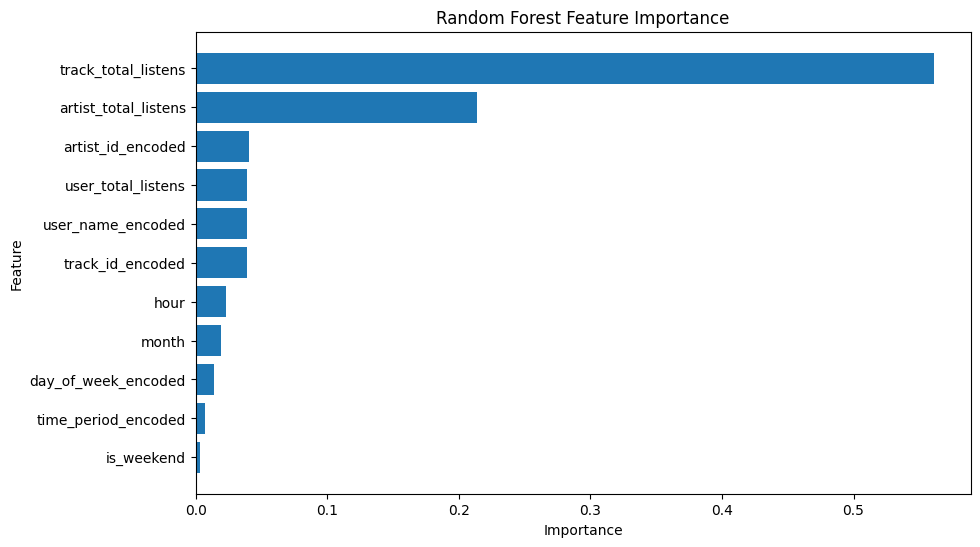

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()


## 13. Simple recommendation function

This recommends tracks that a selected user has not listened to yet, ranked by popularity.


In [14]:
def recommend_tracks_for_user(user_name, top_n=10):
    if user_name not in model_df["user_name"].values:
        return f"User {user_name} not found in sample data."

    listened_tracks = set(
        model_df.loc[model_df["user_name"] == user_name, "track_id"]
    )

    candidates = (
        model_df[~model_df["track_id"].isin(listened_tracks)]
        [["track_id", "track_name", "artist_name", "release_name", "track_total_listens", "artist_total_listens"]]
        .drop_duplicates()
        .sort_values(["track_total_listens", "artist_total_listens"], ascending=False)
        .head(top_n)
    )

    return candidates

sample_user = model_df["user_name"].iloc[0]
print("Sample user:", sample_user)
recommend_tracks_for_user(sample_user, top_n=10)


Sample user: fiveplustwo


,track_id,track_name,artist_name,release_name,track_total_listens,artist_total_listens
11473,adb2a95721c7f11e1daf38dc61a9727e,Tell Me Your Wish (Genie),소녀시대,Tell Me Your Wish,51,51
49940,264bc8f03fa19dc5130e1ac13552706c,Sentimental Skyscraper,Halozy,,30,30
21880,d3f93a8ce458a7f66dfda6456ea82c76,City of Darkness,Funker Vogt,,20,27
10929,0cc68ccfdf197cdd9972b1392cbff1e0,Laat Me,Ramses Shaffy,,18,20
37435,014ce4566cc6f132904063c55acc0a58,Rhubarb,Aphex Twin,,16,125
33421,de1133c2c965214aed84e9c0761470a2,Whole Lotta Love,Led Zeppelin,,14,114
27187,5f0e398bac3beee3cb59e67bf066cc8e,Free,Powerman 5000,,14,25
48440,89627bf5d81f6dfdd75130665f02a3cf,桜の頃,3L,,14,14
5734,86e2182babba72818c4e9f15b1cd99db,高鳴る鼓動 [Being Remix],Ebon,,13,13
26245,675f3b272b0028726d83b8a0715754df,Perfect Time,Máire Brennan,,13,13


## 14. Predict repeat-listen probability

This gives a probability score for repeated listening.


In [15]:
if hasattr(rf_model, "predict_proba"):
    probabilities = rf_model.predict_proba(X_test)[:, 1]

    prediction_results = X_test.copy()
    prediction_results["actual_repeated_listen"] = y_test.values
    prediction_results["predicted_repeated_probability"] = probabilities

    prediction_results.sort_values(
        "predicted_repeated_probability",
        ascending=False
    ).head(10)


## 15. Report explanation

The machine learning enhancement uses the dbt star schema instead of the raw dataset. The central `fact_listening_events` table provides listening events, while dimension tables provide descriptive features such as user, track, artist, release, date, and time. These tables are joined to create a machine learning dataset. The model predicts whether a user is likely to repeatedly listen to a track. Logistic Regression is used as a baseline model, while Random Forest is used as a stronger non-linear model. This enhancement demonstrates how the data warehouse can support future music recommendation and personalization use cases.


## 16. Limitations and future improvements

This notebook is suitable for assignment demonstration. For a stronger production recommendation system, future work can include:

1. Collaborative filtering or matrix factorisation.
2. More historical listening data.
3. Genre, tag, and release-year features.
4. Ranking metrics such as MAP@K or NDCG@K.
5. Separate artist recommendation and track recommendation models.
6. Model deployment as an API or scheduled batch prediction pipeline.
